In [2]:
import pandas as pd


In [3]:
df = pd.read_csv("survey.csv")

In [4]:
df.head()

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


In [5]:
df.shape

(1259, 27)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   Timestamp                  1259 non-null   str  
 1   Age                        1259 non-null   int64
 2   Gender                     1259 non-null   str  
 3   Country                    1259 non-null   str  
 4   state                      744 non-null    str  
 5   self_employed              1241 non-null   str  
 6   family_history             1259 non-null   str  
 7   treatment                  1259 non-null   str  
 8   work_interfere             995 non-null    str  
 9   no_employees               1259 non-null   str  
 10  remote_work                1259 non-null   str  
 11  tech_company               1259 non-null   str  
 12  benefits                   1259 non-null   str  
 13  care_options               1259 non-null   str  
 14  wellness_program           1259 non

In [7]:
df.describe()

,Age
count,1.259000e+03
mean,7.942815e+07
std,2.818299e+09
min,-1.726000e+03
25%,2.700000e+01
50%,3.100000e+01
75%,3.600000e+01
max,1.000000e+11


In [8]:
df = df.drop(columns=["Timestamp", "comments", "state"])

In [9]:
df = df[(df["Age"] >= 15) & (df["Age"] <= 80)]

In [12]:
df['Gender'].head(10)

0    Female
1         M
2      Male
3      Male
4      Male
5      Male
6    Female
7         M
8    Female
9      Male
Name: Gender, dtype: str

In [14]:
df['Gender'].unique()

<StringArray>
[                                        'Female',
                                              'M',
                                           'Male',
                                           'male',
                                         'female',
                                              'm',
                                       'Male-ish',
                                          'maile',
                                   'Trans-female',
                                     'Cis Female',
                                              'F',
                          'something kinda male?',
                                       'Cis Male',
                                          'Woman',
                                              'f',
                                            'Mal',
                                     'Male (CIS)',
                                 'queer/she/they',
                                     'non-binary',
                 

In [15]:
def clean_gender(g):
    g = str(g).strip().lower()
    male_terms = ["male", "m", "cis male", "man", "malr", "cis man"]
    female_terms = ["female", "f", "cis female", "woman", "femake", "cis-female/femme"]
    if g in male_terms:
        return "Male"
    elif g in female_terms:
        return "Female"
    else:
        return "Other"

df["Gender"] = df["Gender"].apply(clean_gender)

In [16]:
df["work_interfere"] = df["work_interfere"].fillna("Not applicable")

In [17]:
df["self_employed"] = df["self_employed"].fillna(df["self_employed"].mode()[0])

In [18]:
df['Country'].unique()

<StringArray>
[         'United States',                 'Canada',         'United Kingdom',
               'Bulgaria',                 'France',               'Portugal',
            'Netherlands',            'Switzerland',                 'Poland',
              'Australia',                'Germany',                 'Russia',
                 'Mexico',                 'Brazil',               'Slovenia',
             'Costa Rica',                'Austria',                'Ireland',
                  'India',           'South Africa',                  'Italy',
                 'Sweden',               'Colombia',                 'Latvia',
                'Romania',                'Belgium',            'New Zealand',
                  'Spain',                'Finland',                'Uruguay',
                 'Israel', 'Bosnia and Herzegovina',                'Hungary',
              'Singapore',                  'Japan',                'Nigeria',
                'Croatia',            

In [19]:
top_countries = df["Country"].value_counts().nlargest(5).index
df["Country"] = df["Country"].apply(lambda c: c if c in top_countries else "Other")

In [20]:
df.shape

(1251, 24)

In [21]:
df.isnull().sum()

Age                          0
Gender                       0
Country                      0
self_employed                0
family_history               0
treatment                    0
work_interfere               0
no_employees                 0
remote_work                  0
tech_company                 0
benefits                     0
care_options                 0
wellness_program             0
seek_help                    0
anonymity                    0
leave                        0
mental_health_consequence    0
phys_health_consequence      0
coworkers                    0
supervisor                   0
mental_health_interview      0
phys_health_interview        0
mental_vs_physical           0
obs_consequence              0
dtype: int64

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [23]:
target = "treatment"
X = df.drop(columns=[target])
y = LabelEncoder().fit_transform(df[target])

In [24]:
encoders = {}
for col in X.select_dtypes(include="object").columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    encoders[col] = le

C:\Users\HP\AppData\Local\Temp\ipykernel_3520\3610474049.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in X.select_dtypes(include="object").columns:


In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [26]:
scaler = StandardScaler()

In [27]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [28]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=7),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
}


In [30]:
results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
    })

results_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False)
print("\nModel Comparison Results:\n")
print(results_df.to_string(index=False))    


Model Comparison Results:

              Model  Accuracy  Precision   Recall  F1 Score
      Random Forest  0.848606   0.824818 0.889764  0.856061
Logistic Regression  0.820717   0.830645 0.811024  0.820717
      Decision Tree  0.804781   0.760000 0.897638  0.823105
                KNN  0.752988   0.798165 0.685039  0.737288


In [31]:
results_df.to_csv("results.csv", index=False)

In [33]:
rf = models["Random Forest"]
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False).head(8)

print("\nTop factors predicting whether someone seeks treatment:")
print(importance_df.to_string(index=False))


Top factors predicting whether someone seeks treatment:
       Feature  Importance
work_interfere    0.341784
           Age    0.080091
family_history    0.068241
  care_options    0.047865
  no_employees    0.042882
       Country    0.038541
         leave    0.035388
      benefits    0.034220


In [34]:
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [35]:
import matplotlib.pyplot as plt


Saved -> results.csv and model_comparison.png


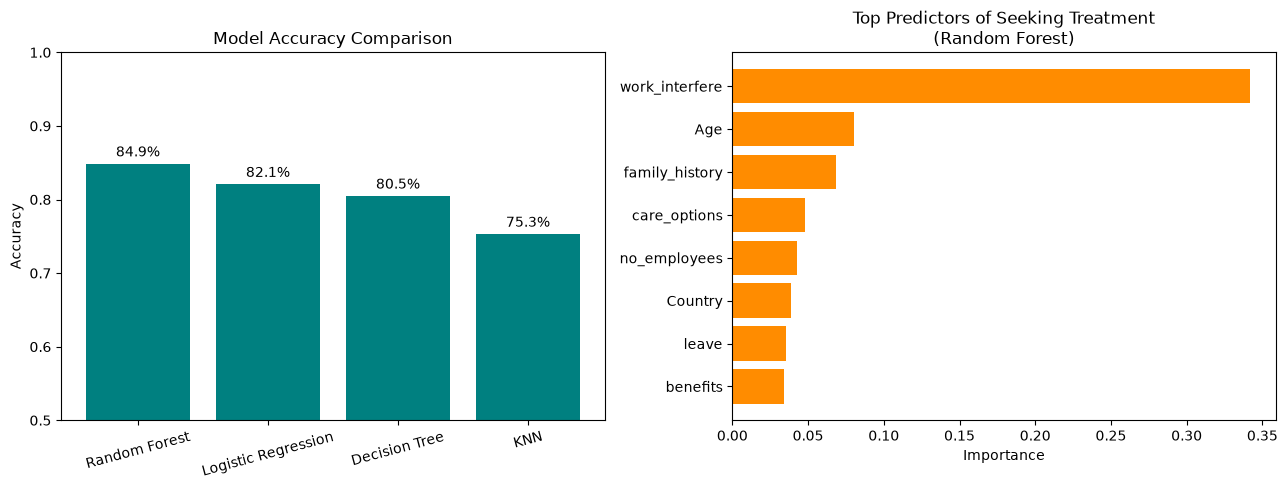

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(results_df["Model"], results_df["Accuracy"], color="teal")
axes[0].set_title("Model Accuracy Comparison")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0.5, 1.0)
axes[0].tick_params(axis="x", rotation=15)
for i, acc in enumerate(results_df["Accuracy"]):
    axes[0].text(i, acc + 0.01, f"{acc:.1%}", ha="center")

axes[1].barh(importance_df["Feature"][::-1], importance_df["Importance"][::-1], color="darkorange")
axes[1].set_title("Top Predictors of Seeking Treatment\n(Random Forest)")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150)
print("\nSaved -> results.csv and model_comparison.png")
